In [5]:
import pandas as pd
import numpy as np

path=r"C:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\data\proceessed\flood_training_data_10k_clean.csv"
df = pd.read_csv(path)
df.head()

,easting,northing,point_id,distance_to_river,aspect,dem,flow_accumulation,twi,slope,flood,rainfall,drainage_density,ext_rainfall,lulc,soil
0,133952.230146,2.249638e+06,0,10993.2705,177.989240,183.269820,18,10.043777,1.200029e+00,0,1714.680084,0.008238,30.779120,40,29
1,206784.841335,2.468185e+06,1,8457.0740,317.784550,282.669430,1,8.483146,2.028161e+00,0,1561.825018,0.006385,34.464436,40,30
2,459671.933327,2.241227e+06,2,3313.8800,57.226437,0.000346,6,12.700654,9.576796e-07,0,1767.091847,0.045409,36.737860,80,36
3,44328.737440,2.570529e+06,3,9742.9820,152.312100,538.788700,2,9.058740,4.337976e+00,0,1424.827479,0.024082,32.841915,10,31
4,60077.196604,2.480489e+06,4,2313.1147,43.902390,298.437530,2,8.486233,7.265088e-01,0,1839.188680,0.027140,32.228870,50,31


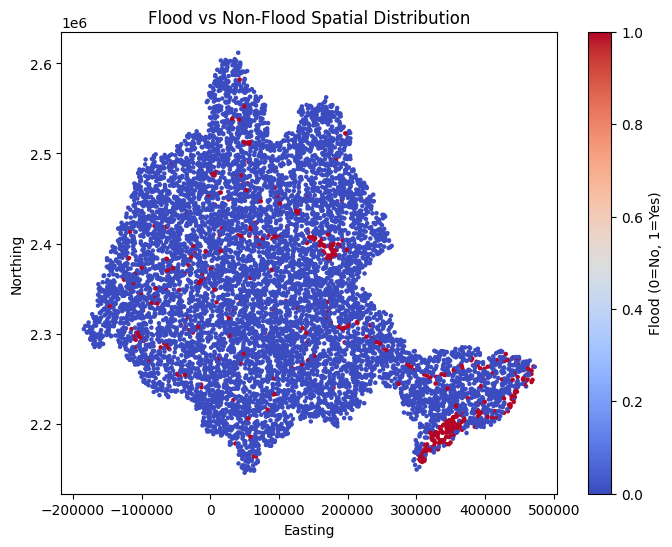

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["easting"],
    df["northing"],
    c=df["flood"],
    cmap="coolwarm",
    s=5
)

plt.xlabel("Easting")
plt.ylabel("Northing")
plt.title("Flood vs Non-Flood Spatial Distribution")

plt.colorbar(label="Flood (0=No, 1=Yes)")

plt.show()

In [7]:
# Feature division
X = df.drop(['flood',"point_id", "easting", "northing"], axis=1)
y = df['flood']
X.columns

Index(['distance_to_river', 'aspect', 'dem', 'flow_accumulation', 'twi',
       'slope', 'rainfall', 'drainage_density', 'ext_rainfall', 'lulc',
       'soil'],
      dtype='object')

In [8]:
# One-hot encode LULC for Logistic Regression
X = pd.get_dummies(X, columns=["lulc"], drop_first=True)

X.head()

,distance_to_river,aspect,dem,flow_accumulation,twi,slope,rainfall,drainage_density,ext_rainfall,soil,lulc_20,lulc_30,lulc_40,lulc_50,lulc_60,lulc_80,lulc_90,lulc_95
0,10993.2705,177.989240,183.269820,18,10.043777,1.200029e+00,1714.680084,0.008238,30.779120,29,False,False,True,False,False,False,False,False
1,8457.0740,317.784550,282.669430,1,8.483146,2.028161e+00,1561.825018,0.006385,34.464436,30,False,False,True,False,False,False,False,False
2,3313.8800,57.226437,0.000346,6,12.700654,9.576796e-07,1767.091847,0.045409,36.737860,36,False,False,False,False,False,True,False,False
3,9742.9820,152.312100,538.788700,2,9.058740,4.337976e+00,1424.827479,0.024082,32.841915,31,False,False,False,False,False,False,False,False
4,2313.1147,43.902390,298.437530,2,8.486233,7.265088e-01,1839.188680,0.027140,32.228870,31,False,False,False,True,False,False,False,False


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.shape, y_train.shape

((6828, 18), (6828,))

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

model = LogisticRegression(max_iter=500)

penalty = ["l1", "l2", "elasticnet"]
c_values = [100, 1, 0.1, 0.01]
solver = ["liblinear", "saga"]
class_weight = [{0: w, 1: y} for w in [1, 10, 50, 100] for y in [1, 10, 50, 100]]

param_grid = [
    {
        "penalty": ["l1"],
        "solver": ["liblinear", "saga"],
        "C": c_values,
        "class_weight": class_weight
    },
    {
        "penalty": ["l2"],
        "solver": ["lbfgs", "newton-cg", "sag", "liblinear", "saga"],
        "C": c_values,
        "class_weight": class_weight
    },
    {
        "penalty": ["elasticnet"],
        "solver": ["saga"],
        "C": c_values,
        "class_weight": class_weight,
        "l1_ratio": [0.5, 0.7]
    }
]

In [12]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [13]:
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="accuracy",
    verbose=2,
    n_jobs=-1
)

In [ ]:
# import warnings
# import joblib
# from google.colab import drive
# warnings.filterwarnings("ignore")

# grid.fit(X_train, y_train)
# try:
#     drive.mount('/content/drive')
#     model_path = '/content/drive/MyDrive/best_logistic_model.pkl'
#     joblib.dump(grid.best_estimator_, model_path)
#     print(f"Trained model saved to Google Drive as: {model_path}")
# except Exception as e:
#     print(f"Could not save to Drive: {e}")

# print("Best Params:", grid.best_params_)
# print("Best Score:", grid.best_score_)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Could not save to Drive: mount failed
Best Params: {'C': 0.01, 'class_weight': {0: 50, 1: 50}, 'l1_ratio': 0.7, 'penalty': 'elasticnet', 'solver': 'saga'}
Best Score: 0.9797888007551258


In [ ]:
# # Save the best model found by GridSearchCV
# import joblib

# joblib.dump(grid.best_estimator_, 'best_logistic_model.pkl')

# print("Trained model saved as 'best_logistic_model.pkl'")

Trained model saved as 'best_logistic_model.pkl'


In [15]:
# Load the trained model
import joblib

classifier_model_path = r"C:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\model_training\logistic_reg\best_logistic_model.pkl"
model = joblib.load(classifier_model_path)

print(model.get_params())

{'C': 0.01, 'class_weight': {0: 50, 1: 50}, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.7, 'max_iter': 500, 'n_jobs': None, 'penalty': 'elasticnet', 'random_state': None, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


c:\Users\ps302\OneDrive\Desktop\Hydrology\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [16]:
best_classifier = model

y_pred = best_classifier.predict(X_test)
y_pred_proba = best_classifier.predict_proba(X_test)
y_pred_proba

array([[0.99261522, 0.00738478],
       [0.97946337, 0.02053663],
       [0.99519948, 0.00480052],
       ...,
       [0.99497296, 0.00502704],
       [0.99456321, 0.00543679],
       [0.9812727 , 0.0187273 ]], shape=(2927, 2))


Top 10 Features:
 feature  importance
     dem    1.257206
 lulc_80    1.171349
   slope    0.885226
     twi    0.686517
 lulc_30    0.674072
    soil    0.561916
 lulc_60    0.507269
 lulc_40    0.372878
rainfall    0.312053
  aspect    0.257052


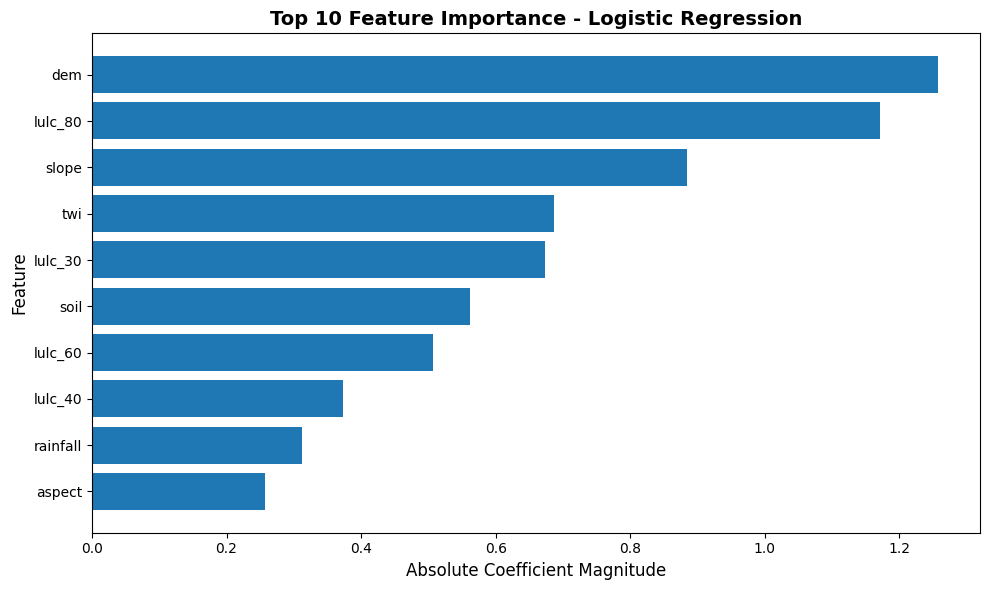

Feature importance plot displayed


In [17]:
# Feature importance for Logistic Regression (use absolute coefficients)
if hasattr(model, "coef_"):
    coef = model.coef_
    if coef.ndim > 1:
        # Binary case gives shape (1, n_features); multiclass gives (n_classes, n_features)
        importance_values = np.mean(np.abs(coef), axis=0)
    else:
        importance_values = np.abs(coef)
else:
    raise AttributeError("The loaded model does not expose 'coef_'.")

feature_importance = (
    pd.DataFrame({"feature": X.columns, "importance": importance_values})
    .sort_values("importance", ascending=False)
    .head(10)
)

print("\nTop 10 Features:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance["importance"])
plt.yticks(range(len(feature_importance)), feature_importance["feature"])
plt.xlabel("Absolute Coefficient Magnitude", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("Top 10 Feature Importance - Logistic Regression", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("Feature importance plot displayed")

Precision: 0.8347826086956521
Recall: 0.6808510638297872
F1 Score: 0.75
ROC AUC: 0.9487610290561215
Confusion Matrix:
 [[2767   19]
 [  45   96]]


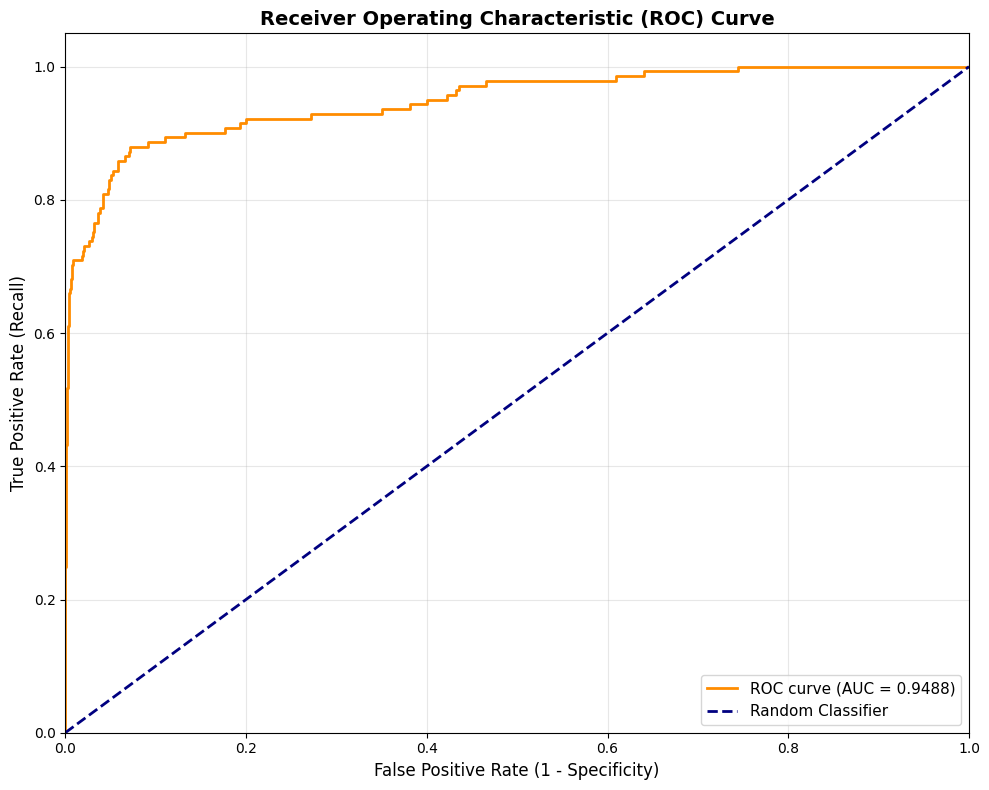

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba[:, 1])) #  probabilities of the positive class
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1]) # probabilities of the positive class

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba[:, 1]):.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Best Threshold finding
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

y_pred_proba = best_classifier.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)

best_threshold = 0.5
best_recall = 0
best_precision = 0
best_f1 = 0

print("Threshold tuning results:\n")

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    rec = recall_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)

    print(f"Threshold={t:.2f} | Recall={rec:.4f} | Precision={prec:.4f} | F1={f1:.4f}")

    # choose threshold with highest recall
    # and keep minimum precision so model does not become useless
    if rec > best_recall and prec >= 0.40:
        best_recall = rec
        best_precision = prec
        best_f1 = f1
        best_threshold = t

print("\nBest Threshold Selected:", best_threshold)
print("Best Recall:", best_recall)
print("Best Precision:", best_precision)
print("Best F1:", best_f1)

# Use selected threshold for final prediction
threshold = float(best_threshold)
y_pred_new = (y_pred_proba >= threshold).astype(int)

print("\nEvaluation using best threshold")
print("Accuracy:", accuracy_score(y_test, y_pred_new))
print("Precision:", precision_score(y_test, y_pred_new, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_new, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_new, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_new))
print("\nClassification Report:\n", classification_report(y_test, y_pred_new, zero_division=0))

Threshold tuning results:

Threshold=0.10 | Recall=0.7872 | Precision=0.4912 | F1=0.6049
Threshold=0.15 | Recall=0.7305 | Precision=0.5988 | F1=0.6581
Threshold=0.20 | Recall=0.7092 | Precision=0.6757 | F1=0.6920
Threshold=0.25 | Recall=0.7092 | Precision=0.7463 | F1=0.7273
Threshold=0.30 | Recall=0.7092 | Precision=0.7576 | F1=0.7326
Threshold=0.35 | Recall=0.7092 | Precision=0.7874 | F1=0.7463
Threshold=0.40 | Recall=0.7021 | Precision=0.8250 | F1=0.7586
Threshold=0.45 | Recall=0.6879 | Precision=0.8291 | F1=0.7519
Threshold=0.50 | Recall=0.6809 | Precision=0.8348 | F1=0.7500
Threshold=0.55 | Recall=0.6738 | Precision=0.8407 | F1=0.7480
Threshold=0.60 | Recall=0.6667 | Precision=0.8393 | F1=0.7431
Threshold=0.65 | Recall=0.6667 | Precision=0.8704 | F1=0.7550
Threshold=0.70 | Recall=0.6525 | Precision=0.8762 | F1=0.7480
Threshold=0.75 | Recall=0.6028 | Precision=0.9043 | F1=0.7234
Threshold=0.80 | Recall=0.5816 | Precision=0.9111 | F1=0.7100
Threshold=0.85 | Recall=0.5532 | Precision=

In [25]:
y_prob = best_classifier.predict_proba(X_test)[:, 1]

y_pred_new = (y_prob >= threshold).astype(int)

Threshold: 0.1
Precision: 0.4911504424778761
Recall: 0.7872340425531915
F1 Score: 0.6049046321525886
ROC AUC: 0.9487610290561215
Confusion Matrix:
 [[2671  115]
 [  30  111]]


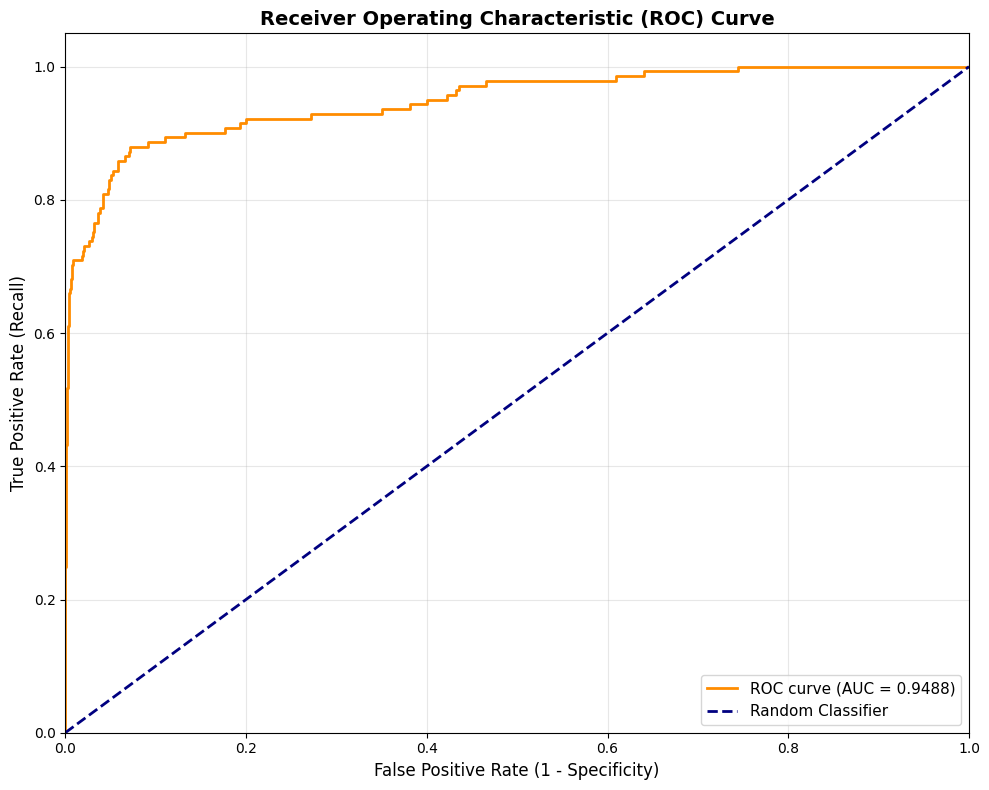

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

print(f"Threshold: {threshold}")
print("Precision:", precision_score(y_test, y_pred_new))
print("Recall:", recall_score(y_test, y_pred_new))
print("F1 Score:", f1_score(y_test, y_pred_new))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_new))

# Calculate ROC curve from probabilities
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# Pediction of new data

new_data = pd.DataFrame({
    "lulc": [40],
    "slope": [5.2],
    "dem": [120],
    "rainfall": [80],
    "flow_accumulation": [300],
    "twi": [10],
    "drainage_density": [2.5],
    "distance_to_river": [200],
    "aspect": [180],
    "ext_rainfall": [100],
    "soil": [3]
})

In [28]:
new_data = pd.get_dummies(new_data, columns=["lulc"], drop_first=True)

In [29]:
new_data = new_data.reindex(columns=X.columns, fill_value=0)

In [30]:
new_data_scaled = scaler.transform(new_data)

In [31]:
y_prob = best_classifier.predict_proba(new_data_scaled)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

print("Prediction:", y_pred[0])
print("Flood Probability:", y_prob[0])

Prediction: 0
Flood Probability: 0.0023483625152069254


{'C': 0.01, 'class_weight': {0: 50, 1: 100}, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 500, 'n_jobs': None, 'penalty': 'l1', 'random_state': None, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


c:\Users\ps302\OneDrive\Desktop\Hydrology\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Training model - without drainage density

In [ ]:
# Feature division
X = df.drop(['flood',"point_id", "easting", "northing", "drainage_density"], axis=1)
y = df['flood']
X.columns

Index(['distance_to_river', 'aspect', 'dem', 'flow_accumulation', 'twi',
       'slope', 'rainfall', 'ext_rainfall', 'lulc', 'soil'],
      dtype='object')

In [ ]:
# Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Applying Hyperparameter tuning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold


#  Stratified CV
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


model = LogisticRegression(max_iter=500)

penalty = ["l1", "l2", "elasticnet"]
c_values = [100, 1, 0.1, 0.01]
solver = ["liblinear", "saga"]
class_weight = [{0: w, 1: y} for w in [1, 10, 50, 100] for y in [1, 10, 50, 100]]

param_grid = [
    {
        "penalty": ["l1"],
        "solver": ["liblinear", "saga"],
        "C": c_values,
        "class_weight": class_weight
    },
    {
        "penalty": ["l2"],
        "solver": ["lbfgs", "newton-cg", "sag", "liblinear", "saga"],
        "C": c_values,
        "class_weight": class_weight
    },
    {
        "penalty": ["elasticnet"],
        "solver": ["saga"],
        "C": c_values,
        "class_weight": class_weight,
        "l1_ratio": [0.5, 0.7]
    }
]


In [ ]:
# Grid Search
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="recall",
    verbose=2,
    n_jobs=-1
)

In [ ]:
# Load the trained model
import joblib

classifier_model_path = r"C:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\model_training\logistic_reg\best_logistic_basic_model_wo_dd.pkl"
model = joblib.load(classifier_model_path)

print(model.get_params())

{'C': 0.01, 'class_weight': {0: 1, 1: 100}, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 500, 'n_jobs': None, 'penalty': 'l1', 'random_state': None, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


c:\Users\ps302\OneDrive\Desktop\Hydrology\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
best_classifier = model

y_pred = best_classifier.predict(X_test)
y_pred_proba = best_classifier.predict_proba(X_test)
y_pred_proba

array([[0.30545403, 0.69454597],
       [0.78916372, 0.21083628],
       [0.11416752, 0.88583248],
       ...,
       [0.37447656, 0.62552344],
       [0.1948728 , 0.8051272 ],
       [0.90050963, 0.09949037]], shape=(3000, 2))


Top 10 Features:
          feature  importance
              dem    0.759743
distance_to_river    0.600237
             lulc    0.503137
flow_accumulation    0.289679
             soil    0.257056
           aspect    0.142271
     ext_rainfall    0.141232
            slope    0.135653
              twi    0.037760
         rainfall    0.000000


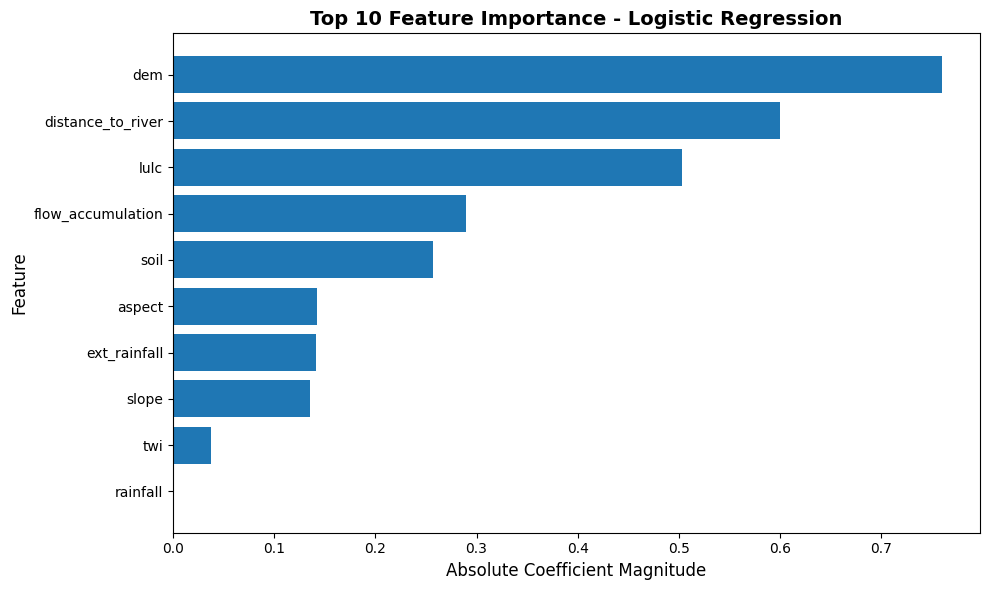

Feature importance plot displayed


In [ ]:
# Feature importance for Logistic Regression (use absolute coefficients)
if hasattr(model, "coef_"):
    coef = model.coef_
    if coef.ndim > 1:
        # Binary case gives shape (1, n_features); multiclass gives (n_classes, n_features)
        importance_values = np.mean(np.abs(coef), axis=0)
    else:
        importance_values = np.abs(coef)
else:
    raise AttributeError("The loaded model does not expose 'coef_'.")

feature_importance = (
    pd.DataFrame({"feature": X.columns, "importance": importance_values})
    .sort_values("importance", ascending=False)
    .head(10)
)

print("\nTop 10 Features:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance["importance"])
plt.yticks(range(len(feature_importance)), feature_importance["feature"])
plt.xlabel("Absolute Coefficient Magnitude", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("Top 10 Feature Importance - Logistic Regression", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("Feature importance plot displayed")

Precision: 0.07199511897498474
Recall: 0.944
F1 Score: 0.13378684807256236
ROC AUC: 0.9079568695652174
Confusion Matrix:
 [[1354 1521]
 [   7  118]]


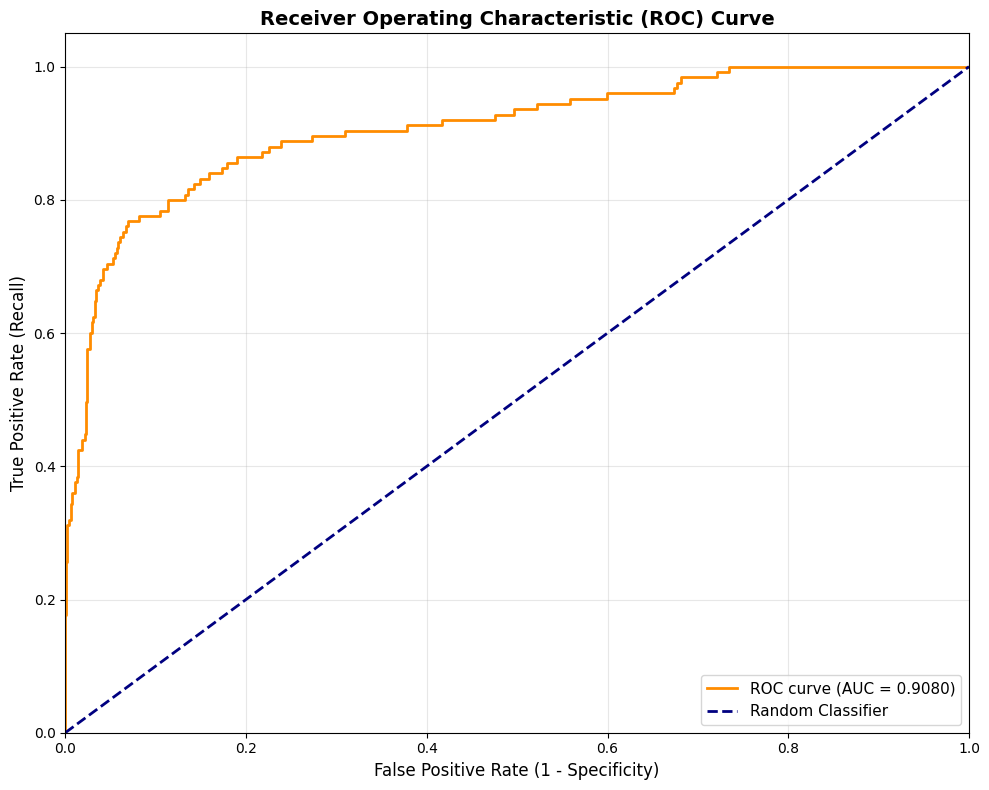

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba[:, 1])) # Use probabilities of the positive class
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1]) # Use probabilities of the positive class

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba[:, 1]):.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()